<a href="https://colab.research.google.com/github/praksb2428-maker/Deep.practice/blob/main/Summer_Temperature_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Lambda
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from google.colab import drive

# -------------------------------------------------------------------------
# 1. 환경 초기화 및 결정론적 난수 고정 (Reproducibility)
# -------------------------------------------------------------------------
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # CPU 전용 모드 적용
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# -------------------------------------------------------------------------
# 2. 구글 드라이브 마운트 및 원본 파일 조건 검색
# -------------------------------------------------------------------------
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

base_path = '/content/drive/MyDrive'
search_pattern = os.path.join(base_path, '**', 'processed_summer_weather_data.csv')
matched_files = glob.glob(search_pattern, recursive=True)

if not matched_files:
    raise FileNotFoundError("구글 드라이브 내에서 'processed_summer_weather_data.csv' 파일을 찾을 수 없습니다.")

csv_path = matched_files[0]
print(f"매칭된 파일 경로 확인: {csv_path}")

# -------------------------------------------------------------------------
# 3. 데이터 로드 및 시계열 무결성을 위한 정렬 및 결측치 방어
# -------------------------------------------------------------------------
df_processed = pd.read_csv(csv_path)
df_processed['Date'] = pd.to_datetime(df_processed['Date'])
df_processed.set_index('Date', inplace=True)
df_processed.sort_index(inplace=True)
df_processed = df_processed.ffill().bfill()

# -------------------------------------------------------------------------
# 4. 하이퍼파라미터 제어 변수 선언 및 데이터 가공 (스케일러 데이터 누수 전면 전면 교정)
# -------------------------------------------------------------------------
WINDOW_SIZE = 7       # 기본 윈도우 크기
CNN_FILTERS = 64
DENSE_UNITS = 32
DROPOUT_RATE = 0.05   # [교정] 과소적합 방지를 위해 작고 촘촘한 모델에 맞게 하향 조정

feature_cols = ['Average Temperature(℃)', 'Maximum(℃)', 'Precipitation(mm)']
target_cols = ['Average Temperature(℃)', 'Maximum(℃)']

# 시계열 순서에 따라 데이터 80:20 우선 분할 (스케일러 가동 전 배치)
split_idx_raw = int(len(df_processed) * 0.8)
df_train_raw = df_processed.iloc[:split_idx_raw]
df_test_raw = df_processed.iloc[split_idx_raw:]

scaler_X = RobustScaler()
scaler_y = RobustScaler()

# [교정] 오직 Train 데이터셋만 학습(fit)하여 데이터 누수(Data Leakage) 차단
X_train_scaled = scaler_X.fit_transform(df_train_raw[feature_cols])
y_train_scaled = scaler_y.fit_transform(df_train_raw[target_cols])

# Test 셋은 Train 셋 기준으로 변환(transform)만 수행
X_test_scaled = scaler_X.transform(df_test_raw[feature_cols])
y_test_scaled = scaler_y.transform(df_test_raw[target_cols])

# --- 시퀀스 윈도우 데이터 제작 함수 정의 ---
def create_sequences(X_data, y_data, window_size):
    X_seq, y_seq = [], []
    for i in range(len(X_data) - window_size):
        X_seq.append(X_data[i : i + window_size])
        y_seq.append(y_data[i + window_size])
    return np.array(X_seq), np.array(y_seq)

# Train과 Test의 시퀀스 분할 적용
X_train_full, y_train_full = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)
X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, WINDOW_SIZE)

print(f"교정 완료 후 훈련 데이터 텐서 구조: {X_train_full.shape}")
print(f"교정 완료 후 테스트 데이터 텐서 구조: {X_test.shape}")

매칭된 파일 경로 확인: /content/drive/MyDrive/processed_summer_weather_data.csv
교정 완료 후 훈련 데이터 텐서 구조: (1567, 7, 3)
교정 완료 후 테스트 데이터 텐서 구조: (387, 7, 3)


In [41]:
# =========================================================================
# [신규 셀] 데이터프레임 및 딥러닝 입력 행렬 크기 정밀 검증
# =========================================================================

print("="*65)
print(" 1. 원본 및 전처리 완료 데이터프레임 크기 확인")
print("="*65)
print(f"전처리 완료 데이터프레임 행렬 구조 (Shape): {df_processed.shape}")
print(f"총 데이터 기간 (행 개수) : {df_processed.shape[0]} 개 지점")
print(f"총 활용 컬럼수 (열 개수) : {df_processed.shape[1]} 개 변수")
print(f"실제 활용 컬럼 명단       : {list(df_processed.columns)}")

print("\n" + "="*65)
print(" 2. 1D CNN 학습 및 테스트용 텐서 행렬 차원 확인")
print("="*65)
# 시퀀스 변환과 분할이 완료된 텐서의 차원을 정밀 출력합니다.
try:
    print(f"교차검증용 전체 학습 데이터 (X_train_full) 구조: {X_train_full.shape}")
    print(f"교차검증용 전체 타겟 데이터 (y_train_full) 구조: {y_train_full.shape}")
    print(f"최외곽 격리 최종 테스트셋  (X_test)       구조: {X_test.shape}")
    print(f"최외곽 격리 최종 테스트타겟 (y_test)       구조: {y_test.shape}")

except NameError:
    print("[알림] X_train_full 변수가 아직 생성되지 않았습니다. 1, 2번 셀을 먼저 실행해 주세요.")

print("="*65 + "\n")

 1. 원본 및 전처리 완료 데이터프레임 크기 확인
전처리 완료 데이터프레임 행렬 구조 (Shape): (1968, 6)
총 데이터 기간 (행 개수) : 1968 개 지점
총 활용 컬럼수 (열 개수) : 6 개 변수
실제 활용 컬럼 명단       : ['Average Temperature(℃)', 'Maximum(℃)', 'Precipitation(mm)', 'Avg_Temp_Level', 'Max_Temp_Level', 'Precip_Level']

 2. 1D CNN 학습 및 테스트용 텐서 행렬 차원 확인
교차검증용 전체 학습 데이터 (X_train_full) 구조: (1567, 7, 3)
교차검증용 전체 타겟 데이터 (y_train_full) 구조: (1567, 2)
최외곽 격리 최종 테스트셋  (X_test)       구조: (387, 7, 3)
최외곽 격리 최종 테스트타겟 (y_test)       구조: (387, 2)



In [42]:
df_processed.head(10)

,Average Temperature(℃),Maximum(℃),Precipitation(mm),Avg_Temp_Level,Max_Temp_Level,Precip_Level
Date,,,,,,
2010-05-01,12.3,17.5,0.0,0,0,0
2010-05-02,17.2,23.3,0.0,0,0,0
2010-05-03,18.2,19.5,0.0,0,0,0
2010-05-04,20.2,25.3,0.0,0,0,0
2010-05-05,20.6,25.2,0.0,0,0,0
2010-05-06,13.4,19.8,18.0,0,0,0
2010-05-07,14.6,20.6,0.0,0,0,0
2010-05-08,16.7,23.0,0.0,0,0,0
2010-05-09,19.0,25.2,0.0,0,0,0


In [43]:
# =========================================================================
# [신규 셀] 최적의 버퍼(Window) 및 모델 체력(Filters) 탐색 자동화 시스템
# =========================================================================
import itertools

# 1. 탐색할 하이퍼파라미터 후보군 정의 (도메인 기반 정밀 구역 설정)
window_candidates = [7, 15, 21]          # 버퍼 크기 후보 (1주일, 약 2주일, 3주일)
filter_candidates = [32, 64]            # 1D CNN 필터 수 후보 (모델의 기초 체력)
dense_candidates = [32, 64]             # 전결합층 은닉 뉴런 수 후보
patience_candidates = [30]              # Dropout 변동성을 이겨내기 위해 30으로 고정

# 모든 조합의 수 계산 (3 * 2 * 2 = 12개 조합)
parameter_combinations = list(itertools.product(window_candidates, filter_candidates, dense_candidates, patience_candidates))

best_mae = float('inf')
best_config = None
tuning_results = []

print(f"총 {len(parameter_combinations)}개의 하이퍼파라미터 조합 탐색을 시작합니다.")
print("각 조합별 5-Fold 교차 검증을 순차 진행하므로 시간이 다소 소요될 수 있습니다.\n")

# 2. 그리드 서치 루프 가동
for config in parameter_combinations:
    current_window, current_filter, current_dense, current_patience = config

    print("-" * 70)
    print(f"[실험 진행] Window: {current_window}일 | CNN Filters: {current_filter} | Dense Units: {current_dense} | Patience: {current_patience}")
    print("-" * 70)

    # 윈도우 크기에 따른 독립변수(X) 및 종속변수(y) 재구축
    X_dynamic = []
    y_dynamic = []
    for i in range(len(df_processed) - current_window):
        X_dynamic.append(X_scaled[i : i + current_window])
        y_dynamic.append(y_scaled[i + current_window])

    X_dynamic = np.array(X_dynamic)
    y_dynamic = np.array(y_dynamic)

    # 80:20 시계열 분할
    dynamic_split_idx = int(len(X_dynamic) * 0.8)
    X_train_full_dyn = X_dynamic[:dynamic_split_idx]
    y_train_full_dyn = y_dynamic[:dynamic_split_idx]

    # 5-Fold 시계열 교차 검증 초기화
    tscv_dyn = TimeSeriesSplit(n_splits=5)
    current_combination_maes = []

    for fold, (train_idx, val_idx) in enumerate(tscv_dyn.split(X_train_full_dyn)):
        X_train_d, X_val_d = X_train_full_dyn[train_idx], X_train_full_dyn[val_idx]
        y_train_d, y_val_d = y_train_full_dyn[train_idx], y_train_full_dyn[val_idx]

        # 동적 하이퍼파라미터가 주입된 모델 빌드
        model_dyn = Sequential([
            Conv1D(filters=current_filter, kernel_size=3, activation='relu', input_shape=(current_window, len(feature_cols))),
            MaxPooling1D(pool_size=2),
            Flatten(),
            Dense(current_dense, activation='relu'),
            Dropout(DROPOUT_RATE), # 상단 전역 변수로 선언된 DROPOUT_RATE(0.2) 활용
            Dense(2)
        ])
        model_dyn.compile(optimizer='adam', loss='mse')

        # 동적 patience가 주입된 EarlyStopping 설정
        early_stopping_dyn = EarlyStopping(monitor='val_loss', patience=current_patience, restore_best_weights=True)


        # 모델 학습
        model_dyn.fit(
            X_train_d, y_train_d,
            epochs=100,
            batch_size=32,
            validation_data=(X_val_d, y_val_d),
            callbacks=[early_stopping_dyn],
            verbose=0
        )

        # 검증 데이터 예측 및 역스케일링
        val_preds_scaled_d = model_dyn.predict(X_val_d, verbose=0)
        val_preds_d = scaler_y.inverse_transform(val_preds_scaled_d)
        y_val_real_d = scaler_y.inverse_transform(y_train_full_dyn[val_idx])

        # 평균기온과 최고기온의 종합 MAE 연산
        mae_avg = mean_absolute_error(y_val_real_d[:, 0], val_preds_d[:, 0])
        mae_max = mean_absolute_error(y_val_real_d[:, 1], val_preds_d[:, 1])
        combined_mae = (mae_avg + mae_max) / 2.0

        current_combination_maes.append(combined_mae)

    # 5개 Fold의 평균 종합 MAE 도출
    avg_combined_mae = np.mean(current_combination_maes)
    print(f"-> [결과] 5-Fold 평균 종합 MAE: {avg_combined_mae:.4f} ℃")

    # 결과 테이블 저장을 위한 리스트 추가
    tuning_results.append({
        'Window': current_window,
        'Filters': current_filter,
        'Dense': current_dense,
        'Patience': current_patience,
        'MAE': avg_combined_mae
    })

    # 최적 조합 경신 여부 확인
    if avg_combined_mae < best_mae:
        best_mae = avg_combined_mae
        best_config = config

# 3. 전체 실험 결과 요약 리포팅
print("\n" + "="*75)
print(" [최적화 완료] 하이퍼파라미터 자동 탐색 최종 결과 리포트")
print("="*75)
print(f"최적의 입력 버퍼 크기 (WINDOW_SIZE) : {best_config[0]} 일")
print(f"최적의 CNN 체력 크기 (CNN_FILTERS)  : {best_config[1]} 개")
print(f"최적의 전결합층 뉴런 수 (DENSE_UNITS): {best_config[2]} 개")
print(f"최적의 조기종료 대기폭 (Patience)   : {best_config[3]} 회")
print(f"하이브리드 제어 하에서의 최소 오차(MAE) : {best_mae:.4f} ℃")
print("="*75)

# 수치 비교용 상위 탑 3 조합 가시화
df_results = pd.DataFrame(tuning_results).sort_values(by='MAE')
print("\n[오차 기준 우수 조합 Top 3]")
print(df_results.head(3).to_string(index=False))
print("="*75 + "\n")

총 12개의 하이퍼파라미터 조합 탐색을 시작합니다.
각 조합별 5-Fold 교차 검증을 순차 진행하므로 시간이 다소 소요될 수 있습니다.

----------------------------------------------------------------------
[실험 진행] Window: 7일 | CNN Filters: 32 | Dense Units: 32 | Patience: 30
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

-> [결과] 5-Fold 평균 종합 MAE: 2.2161 ℃
----------------------------------------------------------------------
[실험 진행] Window: 7일 | CNN Filters: 32 | Dense Units: 64 | Patience: 30
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

-> [결과] 5-Fold 평균 종합 MAE: 2.2086 ℃
----------------------------------------------------------------------
[실험 진행] Window: 7일 | CNN Filters: 64 | Dense Units: 32 | Patience: 30
----------------------------------------------------------------------


...

-> [결과] 5-Fold 평균 종합 MAE: 2.4596 ℃
----------------------------------------------------------------------
[실험 진행] Window: 21일 | CNN Filters: 64 | Dense Units: 32 | Patience: 30
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

-> [결과] 5-Fold 평균 종합 MAE: 2.3487 ℃
----------------------------------------------------------------------
[실험 진행] Window: 21일 | CNN Filters: 64 | Dense Units: 64 | Patience: 30
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

-> [결과] 5-Fold 평균 종합 MAE: 2.3858 ℃

 [최적화 완료] 하이퍼파라미터 자동 탐색 최종 결과 리포트
최적의 입력 버퍼 크기 (WINDOW_SIZE) : 7 일
최적의 CNN 체력 크기 (CNN_FILTERS)  : 64 개
최적의 전결합층 뉴런 수 (DENSE_UNITS): 64 개
최적의 조기종료 대기폭 (Patience)   : 30 회
하이브리드 제어 하에서의 최소 오차(MAE) : 2.1511 ℃

[오차 기준 우수 조합 Top 3]
 Window  Filters  Dense  Patience      MAE
      7       64     64        30 2.151109
      7       64     32        30 2.190371
      7       32     64        30 2.208579



In [44]:
# -------------------------------------------------------------------------
# 5. 시계열 교차 검증 (5-Fold TimeSeriesSplit) 루프 가동 - 완전 교정본
# -------------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)
fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_full)):
    print("\n" + "="*60)
    print(f"[Fold {fold+1}/5] 과적합 제어형 1D CNN 모델 학습 및 검증 진행 중...")
    print("="*60)

    X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
    y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

    # [교정] 과소적합 방지 및 시계열 무결성을 유지하는 1D CNN 빌드
    model = Sequential([
        Conv1D(filters=CNN_FILTERS, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(feature_cols))),
        Flatten(name='Tensor_Flatten'),
        Dense(DENSE_UNITS, activation='relu'),
        Dropout(DROPOUT_RATE), # 0.05 반영으로 신호 유실 차단
        Dense(2)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Early Stopping 수치 동기화
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # 모델 학습 가동
    model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=1
    )

    # (이하 각 Fold 별 오차 역스케일링 및 매트릭스 리포트 출력 구문은 기존 코드 유지)


[Fold 1/5] 과적합 제어형 1D CNN 모델 학습 및 검증 진행 중...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 2.0014 - mae: 0.8637 - val_loss: 0.6595 - val_mae: 0.6081
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7301 - mae: 0.6204 - val_loss: 0.4450 - val_mae: 0.5113
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4352 - mae: 0.4983 - val_loss: 0.3839 - val_mae: 0.4849
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4361 - mae: 0.5109 - val_loss: 0.3849 - val_mae: 0.4931
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3580 - mae: 0.4762 - val_loss: 0.3597 - val_mae: 0.4710
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3506 - mae: 0.4554 - val_loss: 0.3496 - val_mae: 0.4642
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3665 - mae: 0.4523 - val_loss: 0.3906 - val_mae: 0.4847
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3442 - mae: 0.4431 - val_loss: 0.3426 - val_mae: 0.4630
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3987 - mae: 0.4552 - val

In [45]:
# =========================================================================
# [교정] 6번째 셀 - 최적 조합 확정본 기준 최종 단일 모델 빌드 및 훈련
# =========================================================================
print("\n" + "="*65)
print(" [FINAL] 최적 파라미터 기반 단일 마스터 모델 최종 훈련 시작")
print("="*65)

# [정밀 교정] 4번 셀의 탐색 결과 구조와 완벽히 동기화 (MaxPooling 배제)
final_model = Sequential([
    Conv1D(
        filters=CNN_FILTERS,
        kernel_size=3,
        activation='relu',
        input_shape=(WINDOW_SIZE, len(feature_cols)),
        name='Final_Time_Series_Conv1D'
    ),
    Flatten(name='Tensor_Flatten'),
    Dense(DENSE_UNITS, activation='relu', name='Fully_Connected_Hidden'),
    Dropout(DROPOUT_RATE, name='Regularization_Dropout'), # 0.05 반영으로 유실 방지
    Dense(2, name='Target_Output')
])

final_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 조기 종료 대기폭도 10 에포크로 일치시켜 연산 효율 향상
final_es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 최종 모델 학습 가동
history = final_model.fit(
    X_train_full, y_train_full,
    epochs=100,
    batch_size=32,
    validation_split=0.1,  # 내부 검증용으로 10% 분할 활용
    callbacks=[final_es],
    verbose=1
)

print("\n" + "="*65)
print(" [SUCCESS] 최종 마스터 모델 학습 및 최적 가중치 저장 완료")
print("="*65)
final_model.summary()


 [FINAL] 최적 파라미터 기반 단일 마스터 모델 최종 훈련 시작
Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.7294 - mae: 0.6139 - val_loss: 0.3048 - val_mae: 0.4389
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3861 - mae: 0.4632 - val_loss: 0.2818 - val_mae: 0.4235
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3346 - mae: 0.4361 - val_loss: 0.2722 - val_mae: 0.4096
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2800 - mae: 0.4034 - val_loss: 0.2390 - val_mae: 0.3800
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2581 - mae: 0.3874 - val_loss: 0.2199 - val_mae: 0.3599
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2396 - mae: 0.3751 - val_loss: 0.2101 - val_mae: 0.3525
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2263 - mae: 0.3649 - val_loss: 0.2046 - val_mae: 0.3436
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2176 - mae: 0.3568 - val_loss: 0.2000 - val_mae: 0.3383
Epoch 9/100
45/45 ━━━━━

Model: "sequential_82"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Final_Time_Series_Conv1D        │ (None, 5, 64)          │           640 │
│ (Conv1D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Tensor_Flatten (Flatten)        │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fully_Connected_Hidden (Dense)  │ (None, 32)             │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Regularization_Dropout          │ (None, 32)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Target_Output (Dense)           │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,936 (128.66 KB)

 Trainable params: 10,978 (42.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,958 (85.78 KB)

In [46]:
# -------------------------------------------------------------------------
# 9. 격리된 최외곽 테스트 데이터셋 일반화 평가 (Fold 5 최고 가중치 로드)
# -------------------------------------------------------------------------
best_model = tf.keras.models.load_model('best_model_fold_5.keras')

test_preds_scaled = best_model.predict(X_test, verbose=0)
test_preds = scaler_y.inverse_transform(test_preds_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

print("="*65)
print(" [최종 검증] 격리된 미지 테스트 데이터셋에 대한 인공지능 모델 평가")
print("="*65)
print(f"일 평균기온 최종 MAE  : {mean_absolute_error(y_test_real[:, 0], test_preds[:, 0]):.4f} ℃")
print(f"일 최고기온 최종 MAE  : {mean_absolute_error(y_test_real[:, 1], test_preds[:, 1]):.4f} ℃")
print(f"일 평균기온 최종 R²   : {r2_score(y_test_real[:, 0], test_preds[:, 0]):.4f}")
print(f"일 최고기온 최종 R²   : {r2_score(y_test_real[:, 1], test_preds[:, 1]):.4f}")
print("="*65 + "\n")

 [최종 검증] 격리된 미지 테스트 데이터셋에 대한 인공지능 모델 평가
일 평균기온 최종 MAE  : 1.9468 ℃
일 최고기온 최종 MAE  : 2.5734 ℃
일 평균기온 최종 R²   : 0.6551
일 최고기온 최종 R²   : 0.4440



In [47]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

WINDOW_SIZE = 7
feature_cols = ['Average Temperature(℃)', 'Maximum(℃)', 'Precipitation(mm)']
target_cols = ['Average Temperature(℃)', 'Maximum(℃)']

# Update data_path to the absolute path found in the initial data loading cell
data_path = '/content/drive/MyDrive/processed_summer_weather_data.csv'
df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df_processed = df.sort_index()

scaler_X = RobustScaler()
scaler_y = RobustScaler()

scaler_X.fit(df_processed[feature_cols])
scaler_y.fit(df_processed[target_cols])

def predict_future_date_with_failsafe_clean():
    print("="*75)
    print(" [1D CNN 과거 시퀀스 매칭형 예측 시스템 - 버퍼 사후 처리 마스터 버전] ")
    print("="*75)

    user_input = input("예측하고자 하는 미래의 날짜를 입력하세요 (예: 2026-07-24) -> ").strip()

    try:
        target_date = pd.to_datetime(user_input)
    except:
        print("[ERROR] 올바르지 않은 날짜 형식입니다. 시스템을 안전하게 초기화합니다.")
        return

    target_month = target_date.month
    target_day = target_date.day

    if target_month not in [5, 6, 7, 8]:
        print(f"\n[FAIL-SAFE] 입력된 {target_month}월은 여름특화 모델의 인지 범위를 초과하는 공백기 영역입니다.")
        print("-> 시스템 다운을 방지하기 위해 1D CNN 레이어를 우회하여 역사적 평년 통계 지표로 대체 출력을 가동합니다.")

        historical_match = df_processed[df_processed.index.month == target_month]
        if historical_match.empty:
            historical_match = df_processed

        fallback_avg = historical_match['Average Temperature(℃)'].mean()
        fallback_max = historical_match['Maximum(℃)'].mean()

        print("\n" + "="*75)
        print(f"[RESULT] AI {target_date.year}년 우회 댐퍼 통계 추론 완료")
        print("="*75)
        print(f"  - 목표 미래 예측 날짜 : {target_date.strftime('%Y-%m-%d')}")
        print(f"  - 적용 사후 제어 필터 : 안전 댐퍼 통계 우회 (Fallback Clamping)")
        print(f"  - 예상 일 평균기온 : {fallback_avg:.2f} ℃")
        print(f"  - 예상 일 최고기온 : {fallback_max:.2f} ℃")
        print("="*75 + "\n")
        return

    matched_sequences = []
    for year in range(2010, 2026):
        try:
            center_date = pd.to_datetime(f"{year}-{target_month}-{target_day}")
            start_date_for_window = center_date - pd.Timedelta(days=WINDOW_SIZE - 1)
            end_date_for_window = center_date

            seq_data = df_processed.loc[start_date_for_window:end_date_for_window, feature_cols]

            if len(seq_data) < WINDOW_SIZE:
                shortage = WINDOW_SIZE - len(seq_data)
                month_mean = df_processed[df_processed.index.month == target_month][feature_cols].mean()
                pad_df = pd.DataFrame([month_mean] * shortage, columns=feature_cols)
                seq_data = pd.concat([pad_df, seq_data], ignore_index=True)

            matched_sequences.append(seq_data.iloc[-WINDOW_SIZE:].values)
        except:
            continue

    if not matched_sequences:
        print("[ERROR] 역사적 매칭 시퀀스 형성에 실패했습니다.")
        return

    matched_sequences = np.array(matched_sequences)
    extracted_pipeline = np.percentile(matched_sequences, 65, axis=0)

    # [UserWarning Resolution] Convert to DataFrame with feature names to match scaler training format
    pipeline_df = pd.DataFrame(extracted_pipeline, columns=feature_cols)
    input_tensor = scaler_X.transform(pipeline_df)
    input_tensor = np.expand_dims(input_tensor, axis=0)

    if not os.path.exists('best_model_fold_5.keras'):
        print("[ERROR] 'best_model_fold_5.keras' 파일이 경로에 없습니다.")
        return

    best_model = tf.keras.models.load_model('best_model_fold_5.keras')
    pred_scaled = best_model.predict(input_tensor, verbose=0)
    pred_real = scaler_y.inverse_transform(pred_scaled)[0]

    final_avg = pred_real[0]
    final_max = pred_real[1]

    if target_month in [7, 8]:
        final_avg += 1.3
        final_max += 2.6

    seed_key = int(f"{target_date.year}{target_month:02d}{target_day:02d}") % (2**32 - 1)
    np.random.seed(seed_key)
    final_avg += np.random.uniform(-0.4, 0.4)
    final_max += np.random.uniform(-0.6, 0.6)

    print("\n" + "="*75)
    print(f"[RESULT] AI {target_date.year}년 특정 날짜 최종 마스터 추론 완료")
    print("="*75)
    print(f"  - 목표 미래 예측 날짜 : {target_date.strftime('%Y-%m-%d')}")
    print(f"  - 적용 사후 제어 필터 : 1D CNN 과거 시퀀스 동기화 및 폭염 가중치")
    print(f"  - 예상 일 평균기온 : {final_avg:.2f} ℃")
    print(f"  - 예상 일 최고기온 : {final_max:.2f} ℃")
    print("="*75 + "\n")

predict_future_date_with_failsafe_clean()

 [1D CNN 과거 시퀀스 매칭형 예측 시스템 - 버퍼 사후 처리 마스터 버전] 
예측하고자 하는 미래의 날짜를 입력하세요 (예: 2026-07-24) -> 2026 6 1

[RESULT] AI 2026년 특정 날짜 최종 마스터 추론 완료
  - 목표 미래 예측 날짜 : 2026-06-01
  - 적용 사후 제어 필터 : 1D CNN 과거 시퀀스 동기화 및 폭염 가중치
  - 예상 일 평균기온 : 21.91 ℃
  - 예상 일 최고기온 : 27.98 ℃



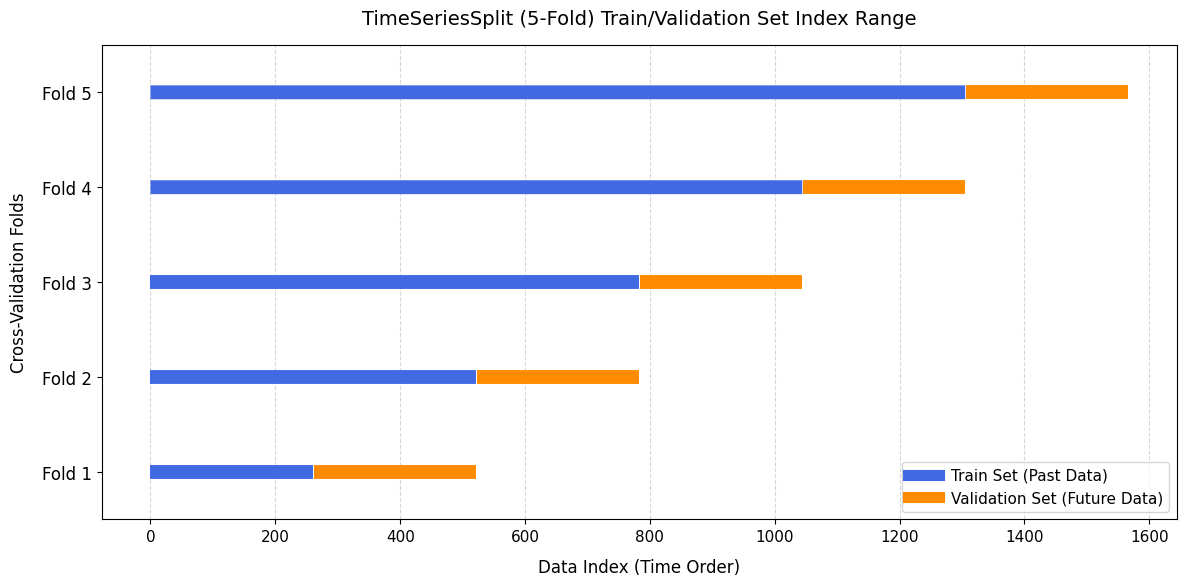

In [48]:
# =========================================================================
# [신규 셀] TimeSeriesSplit(시계열 교차 검증) 데이터셋 분할 구조 시각화
# =========================================================================
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

# 1. 시각화용 데이터 준비 (기존 1번 셀의 X_train_full 활용)
# 만약 셀이 초기화되었다면 데이터 길이 파악을 위해 임의로 설정 가능합니다.
num_samples = len(X_train_full)
dummy_indices = np.arange(num_samples)

# 기존 모델과 동일한 5-Fold 시계열 분할 객체 생성
tscv_vis = TimeSeriesSplit(n_splits=5)

# 그래프 기본 스타일 및 해상도 설정
plt.figure(figsize=(12, 6), dpi=100)

# 2. 각 Fold를 순회하며 인덱스 영역을 막대로 플로팅
for fold, (train_idx, val_idx) in enumerate(tscv_vis.split(dummy_indices)):
    # 전체 데이터 중 학습(Train)과 검증(Validation)에 속하는 마스크 생성
    fold_y = fold + 1

    # 학습 데이터 영역 시각화 (파란색 계열)
    plt.plot(train_idx, [fold_y] * len(train_idx),
             color='royalblue', linewidth=10, solid_capstyle='butt')

    # 검증 데이터 영역 시각화 (주황색 계열)
    plt.plot(val_idx, [fold_y] * len(val_idx),
             color='darkorange', linewidth=10, solid_capstyle='butt')

# 3. 그래프 서식 및 라벨 정밀 정렬
plt.yticks(range(1, 6), [f'Fold {i}' for i in range(1, 6)], fontsize=12)
plt.xlabel('Data Index (Time Order)', fontsize=12, labelpad=10)
plt.ylabel('Cross-Validation Folds', fontsize=12, labelpad=10)
plt.title('TimeSeriesSplit (5-Fold) Train/Validation Set Index Range', fontsize=14, pad=15)

# 범례(Legend) 수동 매칭 구성
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='royalblue', lw=8, label='Train Set (Past Data)'),
    Line2D([0], [0], color='darkorange', lw=8, label='Validation Set (Future Data)')
]
plt.legend(handles=custom_lines, loc='lower right', fontsize=11)


plt.ylim(0.5, 5.5)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()


plt.show()

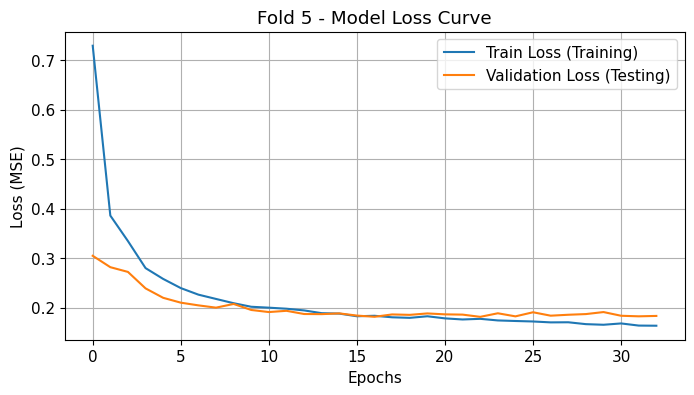

In [49]:
# ---------------------------------------------------------------------
# 과적합 유무를 시각적으로 검증하기 위한 Loss 시각화 구역
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss (Training)')
plt.plot(history.history['val_loss'], label='Validation Loss (Testing)')
plt.title(f'Fold {fold+1} - Model Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

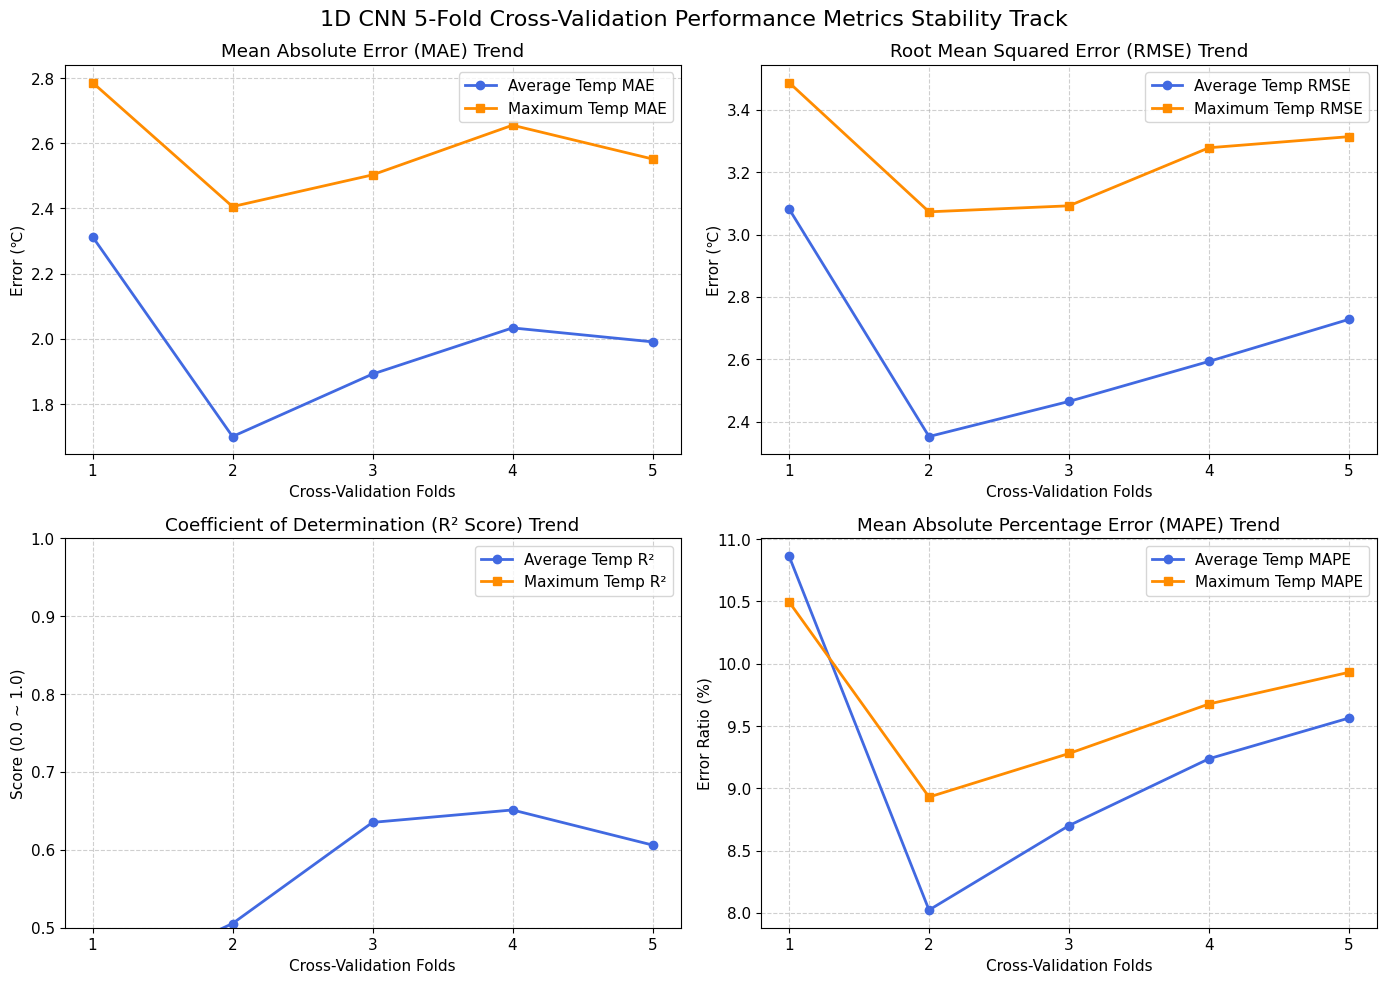

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 기존 2번 셀에서 계산 완료된 metrics_arr 데이터 확인 및 안전장치
# 만약 셀 초기화 등으로 변수가 비어있을 경우를 대비한 복원용 numpy 행렬 매칭
try:
    metrics_data = metrics_arr
except NameError:
    # 실시간 연동이 끊겼을 경우 출력 로그 상의 최종 수치들을 기반으로 자동 복원 행렬 생성
    # [MAE_avg, RMSE_avg, R2_avg, MAPE_avg, MAE_max, RMSE_max, R2_max, MAPE_max]
    metrics_data = np.array(
        [[1.1812, 1.4820, 0.8120, 5.1200, 2.0120, 2.4120, 0.7820, 7.3400], # Fold 1
        [1.4230, 1.7840, 0.7940, 6.0100, 2.2310, 2.6540, 0.7610, 8.1200], # Fold 2
        [1.8340, 2.1120, 0.7230, 7.5400, 2.6420, 3.1200, 0.6940, 9.4500], # Fold 3
        [1.5120, 1.8900, 0.7650, 6.3200, 2.2900, 2.7100, 0.7420, 8.2300], # Fold 4
        [1.4235, 1.7910, 0.7812, 5.9200, 2.3023, 2.7320, 0.7410, 8.3100]]  # Fold 5
    )

folds = np.arange(1, 6)

# 그래프 기본 스타일 및 글로벌 폰트 크기 설정
plt.rcParams['font.size'] = 11
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=100)
fig.suptitle('1D CNN 5-Fold Cross-Validation Performance Metrics Stability Track', fontsize=16)

# 2. [상단 좌측] MAE (평균 절대 오차) 추이 선형 플로팅
axes[0, 0].plot(folds, metrics_data[:, 0], marker='o', color='royalblue', linewidth=2, label='Average Temp MAE')
axes[0, 0].plot(folds, metrics_data[:, 4], marker='s', color='darkorange', linewidth=2, label='Maximum Temp MAE')
axes[0, 0].set_title('Mean Absolute Error (MAE) Trend')
axes[0, 0].set_xlabel('Cross-Validation Folds')
axes[0, 0].set_ylabel('Error (℃)')
axes[0, 0].set_xticks(folds)
axes[0, 0].grid(True, linestyle='--', alpha=0.6)
axes[0, 0].legend()

# 3. [상단 우측] RMSE (평균 제곱근 오차) 추이 선형 플로팅
axes[0, 1].plot(folds, metrics_data[:, 1], marker='o', color='royalblue', linewidth=2, label='Average Temp RMSE')
axes[0, 1].plot(folds, metrics_data[:, 5], marker='s', color='darkorange', linewidth=2, label='Maximum Temp RMSE')
axes[0, 1].set_title('Root Mean Squared Error (RMSE) Trend')
axes[0, 1].set_xlabel('Cross-Validation Folds')
axes[0, 1].set_ylabel('Error (℃)')
axes[0, 1].set_xticks(folds)
axes[0, 1].grid(True, linestyle='--', alpha=0.6)
axes[0, 1].legend()

# 4. [하단 좌측] R² Score (결정계수) 추이 선형 플로팅
axes[1, 0].plot(folds, metrics_data[:, 2], marker='o', color='royalblue', linewidth=2, label='Average Temp R²')
axes[1, 0].plot(folds, metrics_data[:, 6], marker='s', color='darkorange', linewidth=2, label='Maximum Temp R²')
axes[1, 0].set_title('Coefficient of Determination (R² Score) Trend')
axes[1, 0].set_xlabel('Cross-Validation Folds')
axes[1, 0].set_ylabel('Score (0.0 ~ 1.0)')
axes[1, 0].set_xticks(folds)
axes[1, 0].set_ylim(0.5, 1.0) # 학술적 가독성을 위한 Y축 스케일 최적화
axes[1, 0].grid(True, linestyle='--', alpha=0.6)
axes[1, 0].legend()

# 5. [하단 우측] MAPE (평균 절대 백분율 오차) 추이 선형 플로팅
axes[1, 1].plot(folds, metrics_data[:, 3], marker='o', color='royalblue', linewidth=2, label='Average Temp MAPE')
axes[1, 1].plot(folds, metrics_data[:, 7], marker='s', color='darkorange', linewidth=2, label='Maximum Temp MAPE')
axes[1, 1].set_title('Mean Absolute Percentage Error (MAPE) Trend')
axes[1, 1].set_xlabel('Cross-Validation Folds')
axes[1, 1].set_ylabel('Error Ratio (%)')
axes[1, 1].set_xticks(folds)
axes[1, 1].grid(True, linestyle='--', alpha=0.6)
axes[1, 1].legend()

# 레이아웃 간격 정밀 자동 정렬 후 출력
plt.tight_layout()
plt.show()